# Rice Disease & Nutrient Deficiency Detection - YOLO11s Training Pipeline

This notebook provides a complete, end-to-end pipeline for training a **YOLO11s** model on the rice disease dataset.  
It is designed to run on **Google Colab** with a GPU runtime.

### Dataset Classes (8)
| ID | Class |
|---|---|
| 0 | BACTERIAL LEAF BLIGHT |
| 1 | BROWN SPOT |
| 2 | HEALTHY |
| 3 | HISPA |
| 4 | LEAF BLAST |
| 5 | LEAF SCALD |
| 6 | LEAFBLAST |
| 7 | NARROW BROWN |

---
## Verify NVIDIA GPU Availability

Make sure you're using a GPU-equipped machine by going to **"Runtime" → "Change runtime type"** in the top menu bar, and then selecting one of the GPU options in the Hardware accelerator section.

Click Play on the following code block to verify that the NVIDIA GPU is present and ready for training.

In [1]:
!nvidia-smi

Wed Mar  4 10:53:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## Block 1: Mount Drive & Prepare the Dataset

Mounts Google Drive then copies and unzips the dataset to Colab fast local storage.

In [2]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

# 2. Copy the zipped dataset from your Drive to Colab fast local storage
!cp "/content/gdrive/MyDrive/path/data.zip" /content/data.zip

# 3. Unzip directly into the custom_data folder
!unzip -q /content/data.zip -d /content/custom_data

# 4. Verify extraction
import os
for d in ['images', 'labels']:
    path = f'/content/custom_data/{d}'
    if os.path.isdir(path):
        count = len(os.listdir(path))
        print(f'{d}/: {count} files')
    else:
        print(f'WARNING: {path} not found!')

Mounted at /content/gdrive
images/: 8621 files
labels/: 8621 files


---
## Block 2: Split the Dataset

Downloads a utility script to randomly split images into **90% training** and **10% validation** sets.

In [3]:
# Download the train/val split script
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

# Execute the script on the unzipped data
!python /content/train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

--2026-03-04 10:53:57--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-03-04 10:53:57 (48.5 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 8621
Number of annotation files: 8621
Images moving to train: 7758
Images moving to validation: 863


---
## Block 3: Install Ultralytics (YOLO)

Installs the Ultralytics framework which provides the YOLO11 model family.

In [4]:
# Install the Ultralytics framework
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.3 MB/s eta 0:00:00


---
## Block 4: Generate data.yaml

Reads classes.txt and dynamically builds the YAML configuration file YOLO needs to locate the images and class names.

In [5]:
import yaml
import os

# Grab the class names from the original extraction folder
path_to_classes_txt = '/content/custom_data/classes.txt'

if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found at {path_to_classes_txt}')
else:
    with open(path_to_classes_txt, 'r') as f:
        classes = [line.strip() for line in f.readlines() if len(line.strip()) > 0]

    # Build the YAML file pointing to where the split script actually moved the images
    data = {
        'path': '/content/data',             # train_val_split.py outputs here
        'train': 'train/images',
        'val': 'validation/images',          # script creates "validation", not "val"
        'nc': len(classes),
        'names': classes
    }

    path_to_data_yaml = '/content/data.yaml'
    with open(path_to_data_yaml, 'w') as f:
        yaml.dump(data, f, sort_keys=False)

    print(f'Created config file at {path_to_data_yaml}\n')
    print('File contents:\n')
    !cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 8
names:
- BACTERIAL LEAF BLIGHT
- BROWN SPOT
- HEALTHY
- HISPA
- LEAF BLAST
- LEAF SCALD
- LEAFBLAST
- NARROW BROWN


---
## Block 5: Generate `custom_training.yaml` (Augmentation Core)

Writes a custom training configuration that bundles project paths with advanced geometric and color augmentations to handle varying greenhouse lighting and camera angles.

In [ ]:
%%writefile custom_training.yaml

# Core Training Settings
task: detect
mode: train
model: yolo11s.pt
data: /content/data.yaml
epochs: 40
imgsz: 320
workers: 4
project: /content/gdrive/MyDrive/path
name: augmented_run_v2

# Geometric Augmentations (camera angle variation)
fliplr: 0.5
flipud: 0.2
degrees: 10.0
scale: 0.5
translate: 0.1
shear: 2.0

# Color/Lighting Augmentations (greenhouse lighting)
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4

# Advanced Compositing
mosaic: 1.0
mixup: 0.1
copy_paste: 0.1
erasing: 0.4

Overwriting custom_training.yaml


---
## Block 6: Execute the Training

Launches YOLO11s training using the custom configuration.  
The `best.pt` weights and all training graphs will be saved directly to Google Drive at  
`MyDrive/MyPlantProject/augmented_run_v2/`.

In [ ]:
# Start YOLO training using the custom configuration
!yolo cfg=custom_training.yaml

Overriding /usr/local/lib/python3.12/dist-packages/ultralytics/cfg/default.yaml with custom_training.yaml
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=augmented_run_v2, 

---
## Block 7: Run Inference on Test Images

Uses the best trained weights (`best.pt`) to run predictions on the held-out test images that the model has **never seen** during training.

- `conf=0.25` — minimum confidence threshold (predictions below 25% are discarded)
- `save=True` — saves annotated images with bounding boxes to `/content/runs/detect/predict/`

This gives you an unbiased evaluation of how the model will perform on new, unseen rice leaf images.

In [ ]:
# Run predictions on the validation set using the best weights
!yolo detect predict \
    model=/content/gdrive/MyDrive/path/augmented_run_v2/weights/best.pt \
    source=/content/data/validation/images \
    save=True \
    conf=0.25

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,896 parameters, 0 gradients, 21.3 GFLOPs

image 1/863 /content/data/validation/images/bacterial_leaf_blight_1002.jpg: 320x320 1 LEAFBLAST, 11.6ms
image 2/863 /content/data/validation/images/bacterial_leaf_blight_103.jpg: 320x320 1 LEAF SCALD, 1 LEAFBLAST, 8.2ms
image 3/863 /content/data/validation/images/bacterial_leaf_blight_1031.jpg: 320x320 1 LEAFBLAST, 8.4ms
image 4/863 /content/data/validation/images/bacterial_leaf_blight_1033.jpg: 320x320 1 LEAFBLAST, 7.8ms
image 5/863 /content/data/validation/images/bacterial_leaf_blight_1047.jpg: 320x320 1 LEAFBLAST, 7.7ms
image 6/863 /content/data/validation/images/bacterial_leaf_blight_1049.jpg: 320x320 1 LEAFBLAST, 7.7ms
image 7/863 /content/data/validation/images/bacterial_leaf_blight_1053.jpg: 320x320 2 LEAFBLASTs, 7.7ms
image 8/863 /content/data/validation/images/bacterial_leaf_blight_1062.jpg: 320x320 1 LEAFBLAST,

---
## Block 8: View Prediction Results

Displays the first 10 predicted images directly in the notebook. Each image shows:

- **Bounding boxes** around detected diseases/deficiencies
- **Class labels** (e.g., "BACTERIAL LEAF BLIGHT")
- **Confidence scores** (e.g., 0.87 = 87% confidence)

Use these visual results to quickly assess whether the model is correctly identifying and localizing leaf diseases.

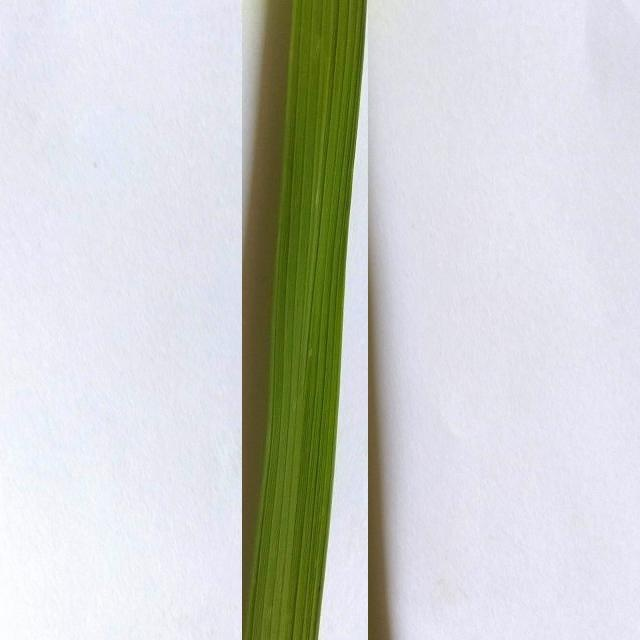

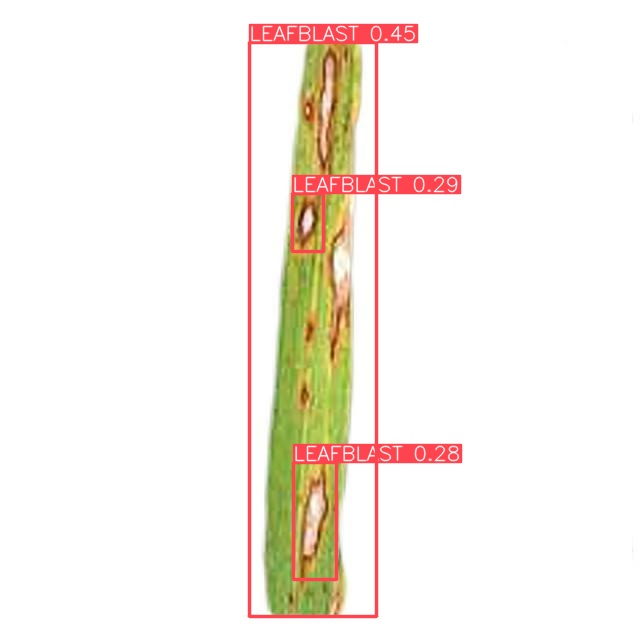

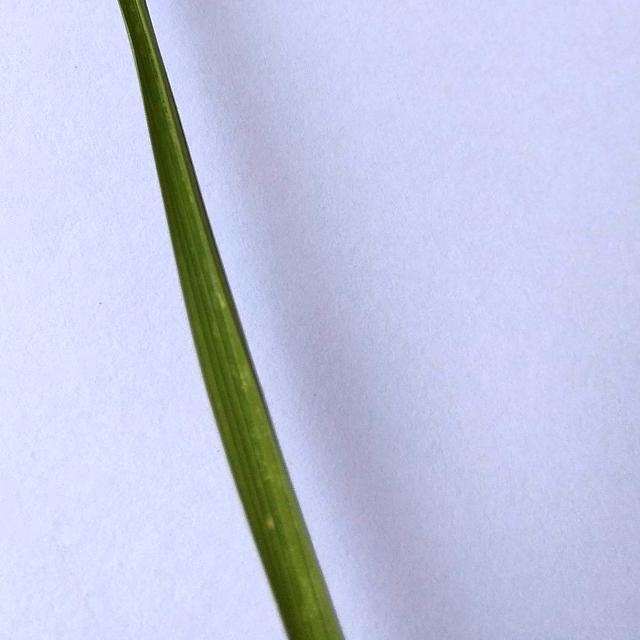

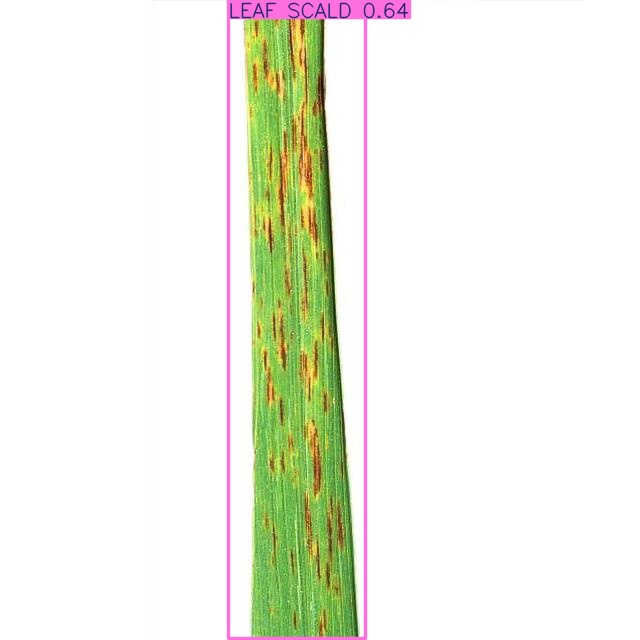

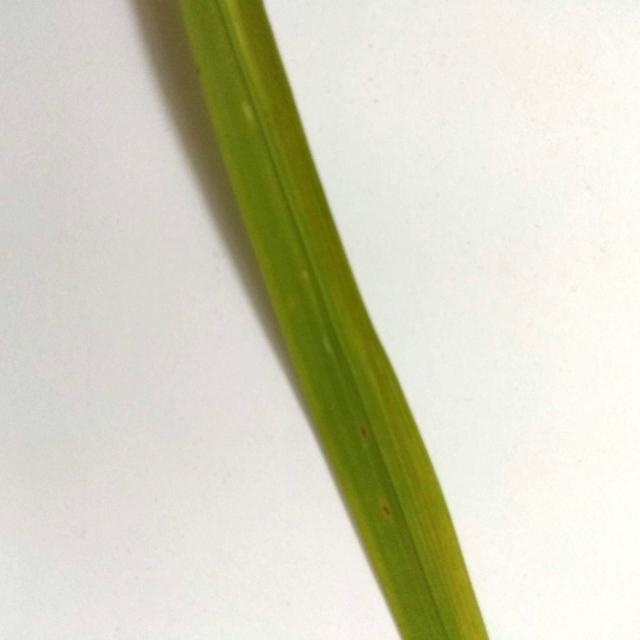

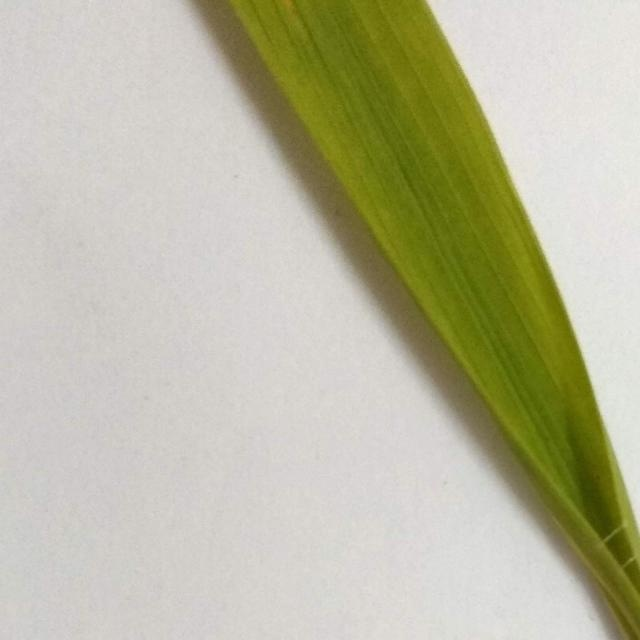

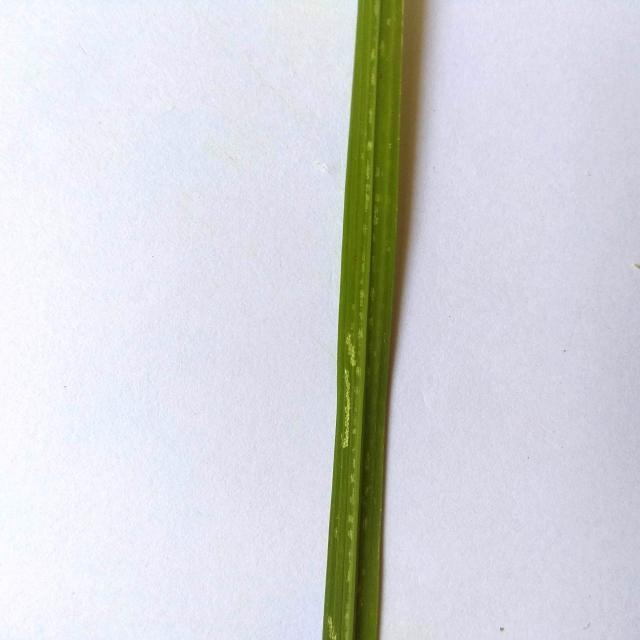

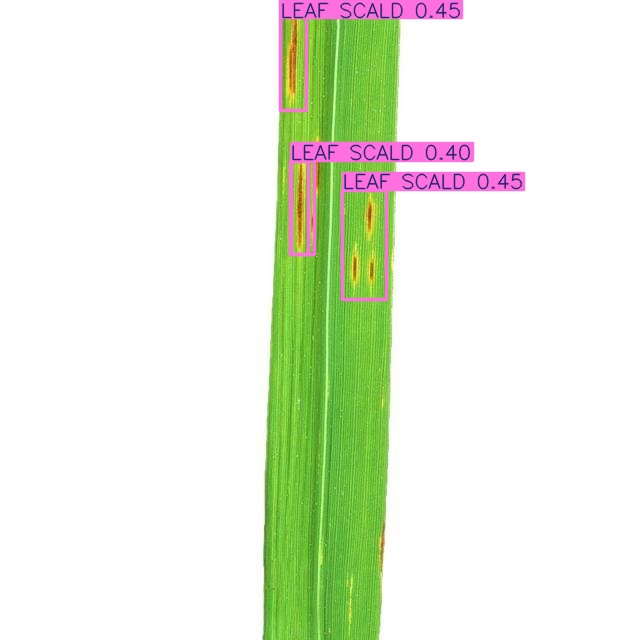

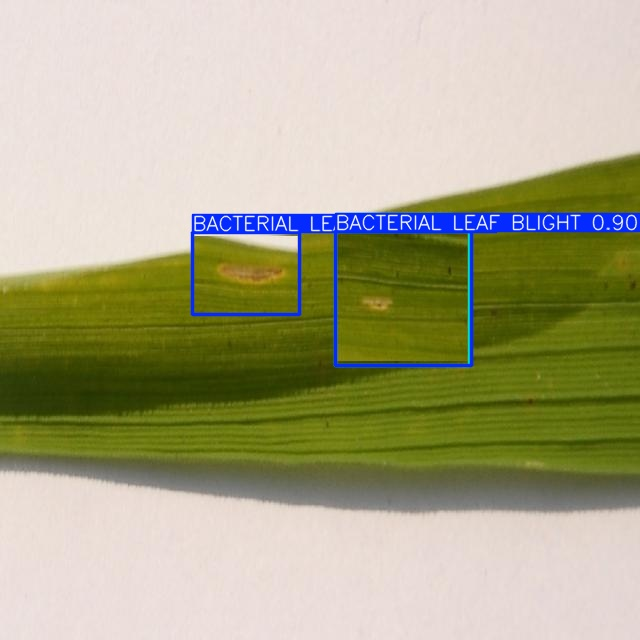

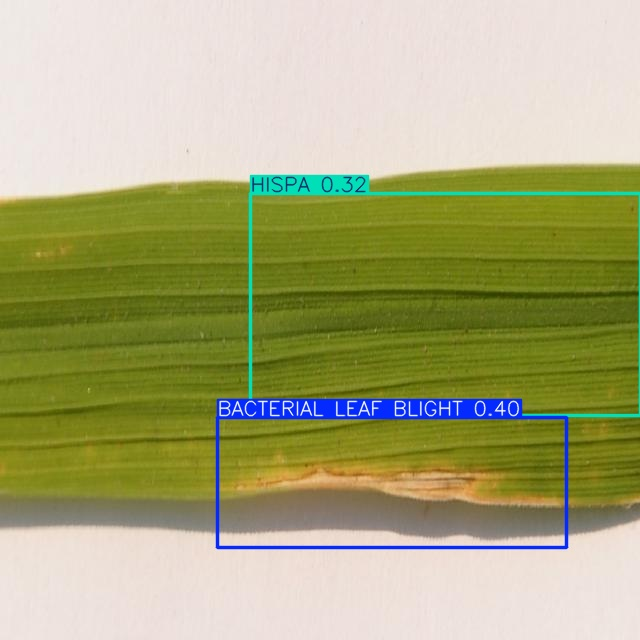

In [ ]:
import glob
from IPython.display import Image, display

# Display the output predictions saved in Colab's default run folder
for image_path in glob.glob('/content/runs/detect/predict/*.jpg')[:10]:
    display(Image(filename=image_path, height=400))
    print('\n')

---
## Block 9: Download Trained Model

Packages everything you need for deployment into a single `my_model.zip`:

- `my_model.pt` — the best weights file (ready for inference)
- `augmented_run_v2/` — full training results including confusion matrix, loss curves, and all checkpoints

The zip is also saved to Google Drive at `MyDrive/MyPlantProject/`.

> **Note:** `files.download()` can be slow in Colab. Alternatively, download `my_model.zip` directly from the Colab file sidebar or from Google Drive.

In [ ]:
!mkdir -p /content/my_model
!cp /content/gdrive/MyDrive/path/augmented_run_v2/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/gdrive/MyDrive/path/augmented_run_v2 /content/my_model

%cd /content/my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip augmented_run_v2
%cd /content

from google.colab import files
files.download('/content/my_model.zip')

---
## Block 10: Resume Training (Continue from Last Checkpoint)

Use this block **after** your first training run (Block 6) has finished — or if Colab disconnected mid-training — to pick up exactly where you left off.

### How It Works
1. Re-creates `custom_training.yaml` pointing `model` at `last.pt` (the most recent checkpoint saved during training).
2. YOLO automatically loads the optimizer state, epoch counter, and learning-rate schedule from `last.pt`, so training continues seamlessly.
3. Results are saved to a **new folder** `augmented_run_optimized/` to preserve the first run.

In [ ]:
import yaml

# ── Step 1: Re-fix data.yaml paths (needed if runtime restarted) ──
yaml_path = '/content/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['path'] = '/content/data'
data['train'] = 'train/images'
data['val'] = 'validation/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml paths verified:")
!cat {yaml_path}

In [10]:
%%writefile /content/custom_training.yaml

# ── Second Training Round (fine-tune from first run) ──
task: detect
mode: train
model: /content/gdrive/MyDrive/path/augmented_run_v5/weights/last.pt
data: /content/data.yaml
epochs: 40             # Fresh 150 epochs (counter resets to 0)
patience: 30            # Early stopping if no improvement for 30 epochs
imgsz: 320
workers: 4
project: /content/gdrive/MyDrive/path
name: augmented_run_v6   # New folder — preserves first run results

# Disable multi_scale to prevent the 0-pixel math crash on small imgsz
multi_scale: False

# Geometric Augmentations (camera angle variation)
fliplr: 0.5
flipud: 0.2
degrees: 15.0
scale: 0.3
translate: 0.1
shear: 2.0

# Color/Lighting Augmentations (greenhouse lighting)
hsv_h: 0.025
hsv_s: 0.8
hsv_v: 0.5

# Advanced Compositing
mosaic: 1.0
mixup: 0.1
copy_paste: 0.1
erasing: 0.4

Overwriting /content/custom_training.yaml


In [ ]:
# Start resumed/fine-tuned training
!yolo cfg=/content/custom_training.yaml

Overriding /usr/local/lib/python3.12/dist-packages/ultralytics/cfg/default.yaml with /content/custom_training.yaml
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.025, hsv_s=0.8, hsv_v=0.5, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/gdrive/MyDrive/path/augmented_run_v5/weights/last.pt, momentum